# Disease Prediction Model 🩺

**Author:** Bernadette Burks  
**Date:** September 14, 2025  

---

## Overview

This Disease Prediction Model is based on a GeeksforGeeks tutorial:
https://www.geeksforgeeks.org/machine-learning/disease-prediction-using-machine-learning/. The primary goal of this model is to explore how machine learning can assist in identifying diseases based on symptom patterns in datasets.

---

## Imports

In [1]:
# Module imports from Main.py are displayed as following:

# from src.training import models
# from src.evaluation import plot_confusion
# from src.prediction import predict_disease
# from src.preprocess import X_resampled, y_resampled

# See individual files for more details on the libraries used in each module.


---

## Load Dataset

In [2]:
import pandas as pd
data = pd.read_csv(r'C:\improved_disease_dataset.csv')


---

## Preprocessing

In [3]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Data encoding
encoder = LabelEncoder()
data["disease"] = encoder.fit_transform(data["disease"])

# Symptom index creation
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Symptom index mapping
symptom_index = {col: idx for idx, col in enumerate(X.columns)}

# Resampling to address class imbalance
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Ensure no NaN values and correct shape
X_resampled = X_resampled.fillna(0)
if len(y_resampled.shape) > 1:
    y_resampled = y_resampled.values.ravel()


---

## Training

In [4]:
from src.preprocess import X_resampled, y_resampled
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

rf_model = RandomForestClassifier(random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
svm_model = SVC()

rf_model.fit(X_resampled, y_resampled)
dt_model.fit(X_resampled, y_resampled)
svm_model.fit(X_resampled, y_resampled)

models = {
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    "SVM": svm_model
}


---

## Evaluation

Random Forest
[0.56140351 0.55263158 0.54093567 0.53508772 0.52339181]
0.5426900584795321
Decision Tree
[0.5497076  0.54239766 0.53508772 0.53654971 0.52777778]
0.5383040935672515
SVM
[0.51315789 0.51169591 0.49707602 0.48245614 0.49561404]
0.5


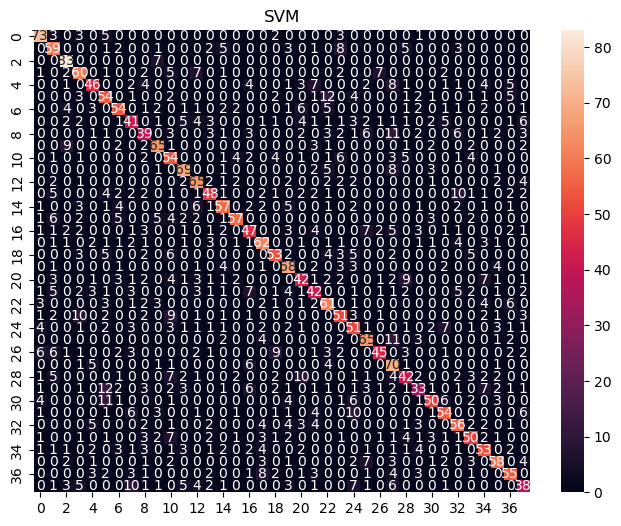

SVM 0.6052631578947368


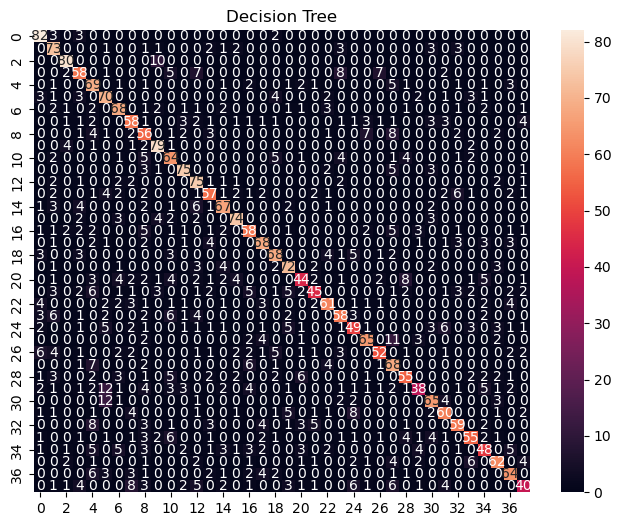

Decision Tree 0.689766081871345


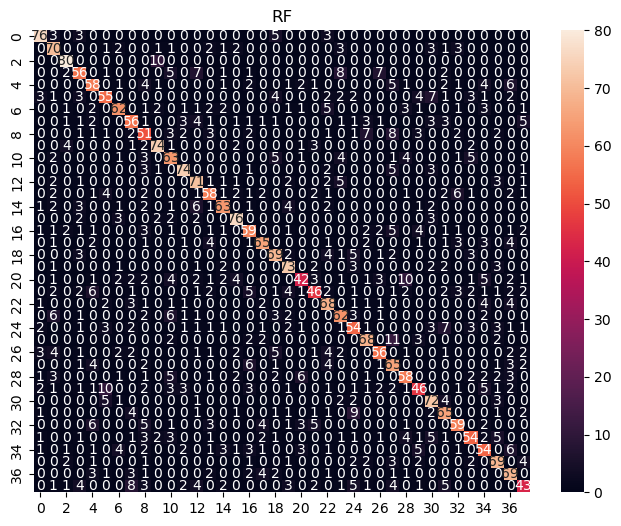

RF 0.689766081871345


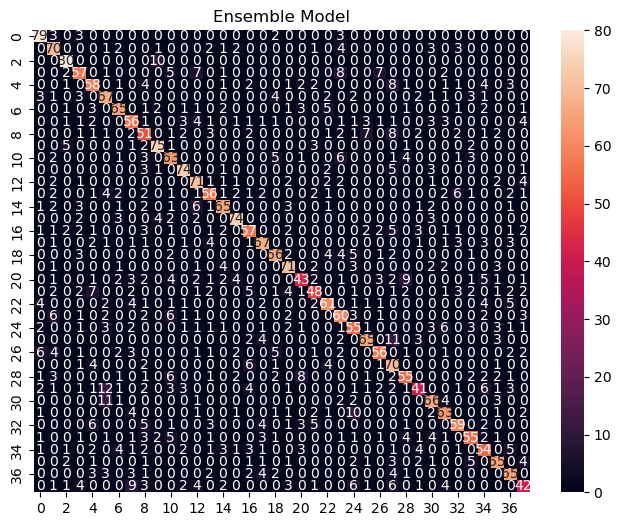

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from statistics import mode
import matplotlib.pyplot as plt
import seaborn as sns
from src.training import models, rf_model, dt_model, svm_model
from src.preprocess import X_resampled, y_resampled

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring="accuracy")
    print(name)
    print(scores)
    print(scores.mean())


def plot_confusion(model, X, y, title):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.show()

    print(title, accuracy_score(y, preds))
    return preds


svm_preds = plot_confusion(svm_model, X_resampled, y_resampled, "SVM")
dt_preds = plot_confusion(dt_model, X_resampled, y_resampled, "Decision Tree")
rf_preds = plot_confusion(rf_model, X_resampled, y_resampled, "RF")

final_preds = [mode([i, j, k]) for i, j, k in zip(svm_preds, dt_preds, rf_preds)]

cm = confusion_matrix(y_resampled, final_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Ensemble Model")
plt.show()


---

## Prediction

In [6]:
import pandas as pd
from statistics import mode
from src.training import rf_model, dt_model, svm_model
from src.preprocess import symptom_index, encoder, X_resampled

symptoms = X_resampled.columns


def predict_disease(input_symptoms):
    input_symptoms = input_symptoms.split(",")

    input_data = [0] * len(symptom_index)

    for symptom in input_symptoms:
        symptom = symptom.strip()
        if symptom in symptom_index:
            input_data[symptom_index[symptom]] = 1

    input_df = pd.DataFrame([input_data], columns=symptoms)

    rf_pred = encoder.classes_[rf_model.predict(input_df)[0]]
    dt_pred = encoder.classes_[dt_model.predict(input_df)[0]]
    svm_pred = encoder.classes_[svm_model.predict(input_df)[0]]

    final_pred = mode([rf_pred, dt_pred, svm_pred])

    return {
        "Random Forest": rf_pred,
        "Decision Tree": dt_pred,
        "SVM": svm_pred,
        "Final Prediction": final_pred
    }


---

## Conclusions

This project demonstrates the potential of machine learning for supporting clinical diagnostic prediction.

Future improvements may include:

- Larger real-world datasets  
- Additional performance metrics  
- Model interpretability tools  